In [2]:
from sklearn.datasets import fetch_olivetti_faces

faces = fetch_olivetti_faces(return_X_y=True)[0]

faces.shape

(400, 4096)

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99, random_state=42)
X_reduced = pca.fit_transform(X)

In [42]:
X_reduced.shape

(400, 260)

In [40]:
X = X_reduced

In [43]:
X

array([[ 6.4326015 ,  0.7036773 , -1.4300195 , ..., -0.06898249,
        -0.13006362, -0.16854815],
       [ 1.0759029 ,  6.697333  ,  1.8428044 , ...,  0.02725761,
        -0.07037814,  0.076836  ],
       [ 5.29295   ,  1.5424999 ,  0.22595696, ...,  0.13833372,
        -0.0514586 ,  0.06332225],
       ...,
       [-2.0407634 ,  1.5096104 ,  3.4487314 , ..., -0.08767195,
         0.0862071 ,  0.01713646],
       [ 5.165222  , -8.096765  , -0.67100906, ...,  0.09199288,
        -0.08986872, -0.02437367],
       [ 1.1505016 , -2.4350338 ,  1.1894928 , ..., -0.03528742,
         0.01012374, -0.01756409]], shape=(400, 260), dtype=float32)

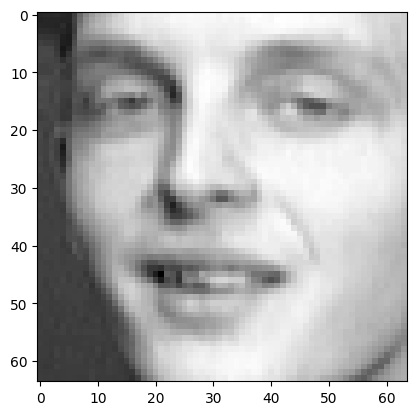

In [12]:
from matplotlib import pyplot as plt

n = 398

plt.imshow(faces[n].reshape(64, 64), cmap='gray')
plt.show()

In [50]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

clusters_kmeans = len(set(labels_kmeans)) - (1 if -1 in labels_kmeans else 0)

In [51]:
clusters_kmeans

5

In [49]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3, min_samples=5)
labels_db = dbscan.fit_predict(X)

clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)

In [48]:
clusters_db

0

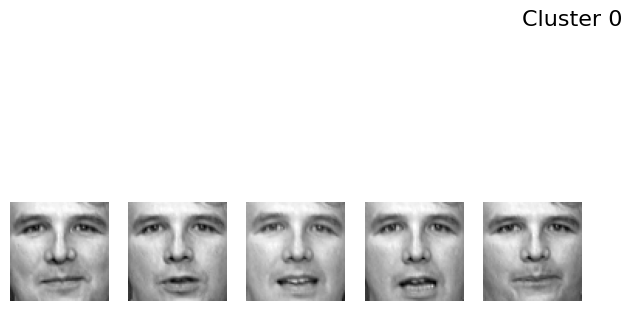

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def plot_faces(images, labels_db, cluster_id, h=64, w=64, n=10):
    idx = np.where(labels_db == cluster_id)[0][:n]
    plt.figure(figsize=(15, 5))
    for i, image_idx in enumerate(idx):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[image_idx].reshape((h, w)), cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Cluster {cluster_id}", fontsize=16)
    plt.show()

plot_faces(X, labels_db, cluster_id=0, n=10)
